<a href="https://colab.research.google.com/github/ihilesen/ihilesen/blob/main/Cancer_patients_2015_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **My first task is to import the packages i need for analysis and building my model**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### **the dataset is imported using pandas in python.**

In [3]:
capatients = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/Stretch project data/Cancer/global_cancer_patients_2015_2024.csv')
capatients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

## **The next step is to make a copy of the dataset and clean the data**

In [4]:
capatients_copy = capatients.copy()
capatients_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

**The dataset collates information on cancer patients diagnosed between 2015 and 2024. This information as seen above includes 50000 entries and 15 columns.**

clean the dataset

In [5]:
capatients_missing = capatients.isnull().sum()
capatients_missing

,0
Patient_ID,0
Age,0
Gender,0
Country_Region,0
Year,0
Genetic_Risk,0
Air_Pollution,0
Alcohol_Use,0
Smoking,0
Obesity_Level,0


There are no missing values in the data. Next we check that the data is uniform

In [6]:
capatients.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

I perform a brief exploration to chack the number represented in the data, the mean, the minimun and maximum values and the standard deviations.

In [7]:
capatients.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


The next step is to find out the unique values.

In [8]:
capatients_gender = capatients['Gender'].value_counts()
capatients_gender

,count
Gender,
Male,16796
Female,16709
Other,16495


In [9]:
capatients_Country_region = capatients['Country_Region'].value_counts()
capatients_Country_region

,count
Country_Region,
Australia,5092
UK,5060
USA,5060
India,5040
Germany,5024
Russia,5017
Brazil,5004
Pakistan,4926
China,4913


In [10]:
capatients_type = capatients['Cancer_Type'].value_counts()
capatients_type

,count
Cancer_Type,
Colon,6376
Prostate,6308
Leukemia,6266
Liver,6249
Skin,6231
Cervical,6222
Breast,6189
Lung,6159


In [11]:
pivot_capatients = capatients.pivot_table(index='Cancer_Type', columns='Gender', values='Age', aggfunc='count')
pivot_capatients

Gender,Female,Male,Other
Cancer_Type,,,
Breast,2051,2080,2058
Cervical,2160,2028,2034
Colon,2108,2147,2121
Leukemia,2081,2092,2093
Liver,2064,2091,2094
Lung,2067,2103,1989
Prostate,2113,2138,2057
Skin,2065,2117,2049


In [12]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=pivot_capatients)

https://docs.google.com/spreadsheets/d/1b9m2i7c5KaRX_YQ2-XHbrBNhK5ES0--MMLRDBZSIqNA/edit#gid=0


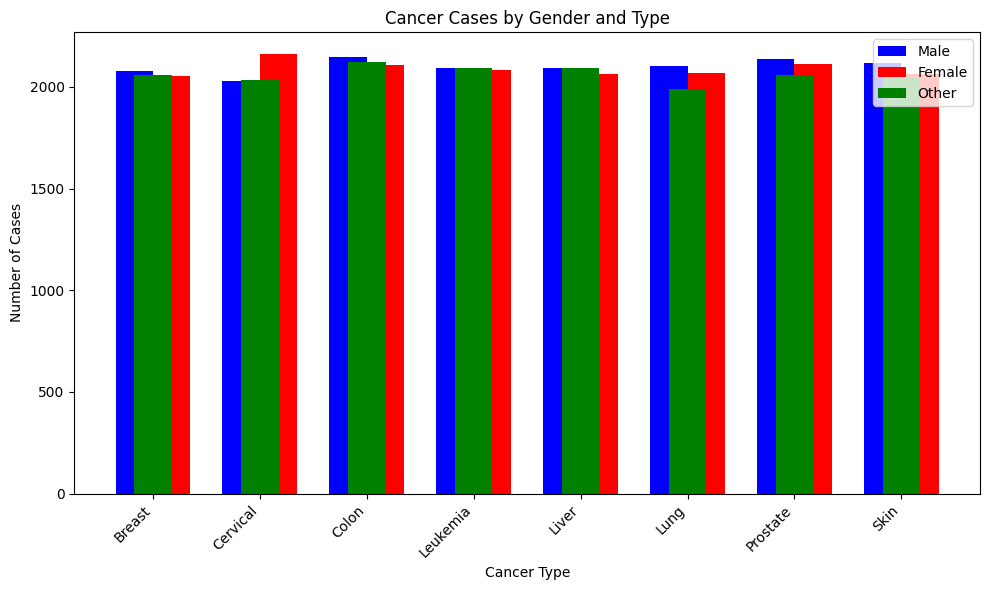

In [13]:
labels = pivot_capatients.index
men_counts = pivot_capatients['Male']
women_counts = pivot_capatients['Female']
other_counts = pivot_capatients['Other']
x= np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, men_counts, width, label='Male', color='blue')
ax.bar(x + width/2, women_counts, width, label='Female', color='red')
ax.bar(x, other_counts, width, label='Other', color='green')

# Add labels and title
ax.set_xlabel('Cancer Type')
ax.set_ylabel('Number of Cases')
ax.set_title('Cancer Cases by Gender and Type')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

In [14]:
capatients_year = capatients['Year'].value_counts()
capatients_year

,count
Year,
2016,5094
2020,5079
2019,5065
2017,5037
2015,5012
2024,4994
2021,4967
2018,4936
2023,4935
